In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('mlp_dataset.csv')
df.head()

,Product,Issue,Company,State,Complaint_length,Word_count,month,day_of_week,hour,Risk
0,Checking or savings account,Managing an account,AMERIS BANCORP,GA,1002,188,1,Thursday,2,0
1,Debt collection,Attempts to collect debt not owed,"Kriya Capital, LLC",GA,2039,332,1,Thursday,3,1
2,Debt collection,Took or threatened to take negative or legal a...,Rosebud Economic Development Corporation,TX,530,85,1,Thursday,0,1
3,Debt collection,Took or threatened to take negative or legal a...,"Portfolio Recovery Associates, LLC",TX,430,74,1,Thursday,0,0
4,Credit card,Other,"EQUIFAX, INC.",IL,182,31,1,Thursday,0,1


In [5]:
df.shape

(53898, 10)

В рассматриваемом датасете мы имеем 53 898 жалобы и 10 признаков

Название признаков

In [6]:
df.columns

Index(['Product', 'Issue', 'Company', 'State', 'Complaint_length',
       'Word_count', 'month', 'day_of_week', 'hour', 'Risk'],
      dtype='object')

1. Разделим признаки на три группы: категориальные, числовые и целевая переменная.

In [7]:
cat_cols = ['Product', 'Issue', 'Company', 'State', 'day_of_week']
num_cols = ['Complaint_length', 'Word_count', 'month', 'hour']
target = 'Risk'

Выведем в таблицу с признаками по группам

In [8]:
cols_info = pd.DataFrame({'Column': df.columns,'Type': df.dtypes.values})
cols_info

,Column,Type
0,Product,object
1,Issue,object
2,Company,object
3,State,object
4,Complaint_length,int64
5,Word_count,int64
6,month,int64
7,day_of_week,object
8,hour,int64
9,Risk,int64


Количество категорий в категориальных признаках

In [9]:
cat_info = {}
for i in cat_cols:
    cat_info[i] = df[i].nunique()
cat_info_table = pd.DataFrame(cat_info.items(), columns=['Column', 'Unique values'])
cat_info_table

,Column,Unique values
0,Product,5
1,Issue,11
2,Company,1417
3,State,57
4,day_of_week,7


Визуализируем количество категорий

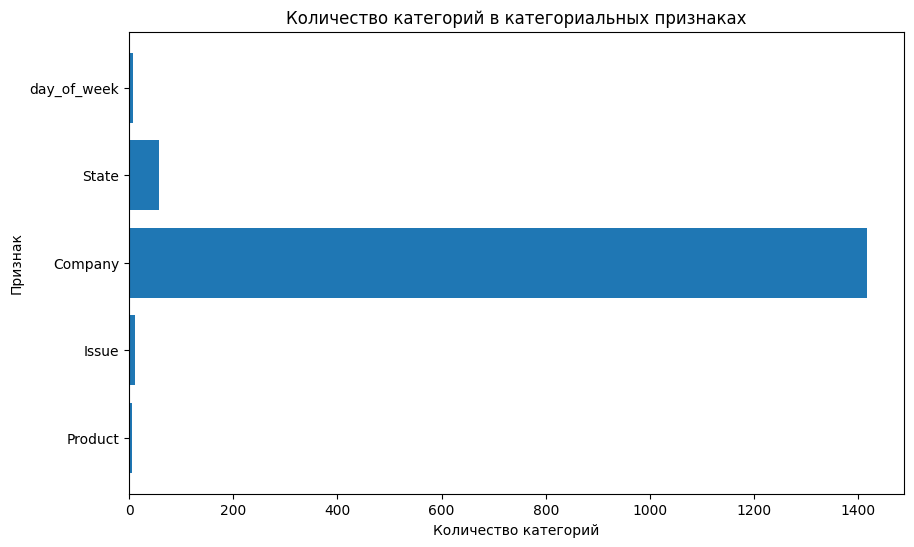

In [10]:
plt.figure(figsize=(10, 6))
plt.barh(cat_info_table['Column'], cat_info_table['Unique values'])
plt.title('Количество категорий в категориальных признаках')
plt.xlabel('Количество категорий')
plt.ylabel('Признак')
plt.show()

Для анализа используется датасет, содержащий 53 898 обращений клиентов к финансовым организациям, другими словами, жалобы. Каждая запись включает информацию о типе финансового продукта, характере проблемы, компании, регионе клиента, времени подачи обращения и характеристиках текста жалобы.

Наибольшее количество уникальных значений содержится в признаке Company, что говорит о широком охвате финансовых организаций при анализе.

2. Посчитаем количество объектов для каждого класса по целевой переменной

In [11]:
df['Risk'].value_counts()

,count
Risk,
0,42078
1,11820


In [12]:
risk_table = df['Risk'].value_counts().reset_index()
risk_table.columns = ['Risk', 'Count']
risk_table['Percent'] = risk_table['Count'] / risk_table['Count'].sum() * 100
risk_table

,Risk,Count,Percent
0,0,42078,78.069687
1,1,11820,21.930313


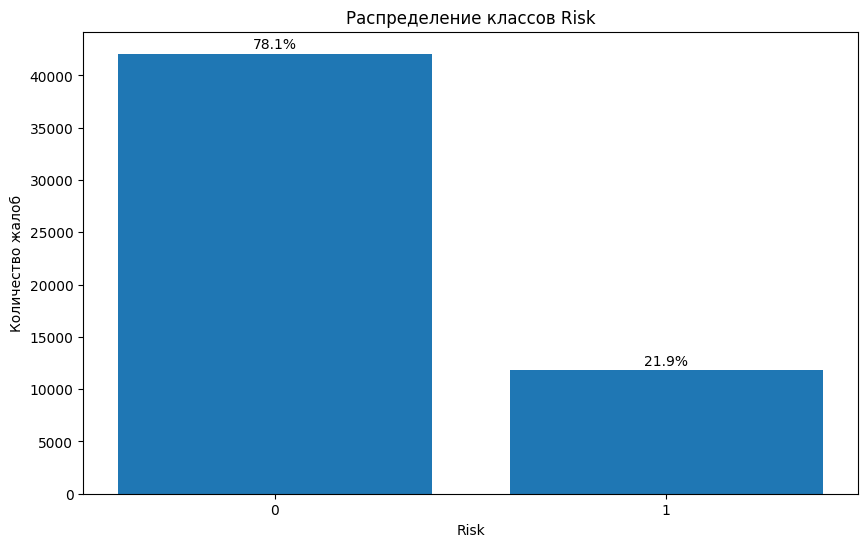

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(risk_table['Risk'].astype(str), risk_table['Count'])
for i in range(len(risk_table)):
    plt.text(i, risk_table['Count'][i] + 500, str(round(risk_table['Percent'][i], 1)) + '%', ha = 'center')

plt.title('Распределение классов Risk')
plt.xlabel('Risk')
plt.ylabel('Количество жалоб')
plt.show()

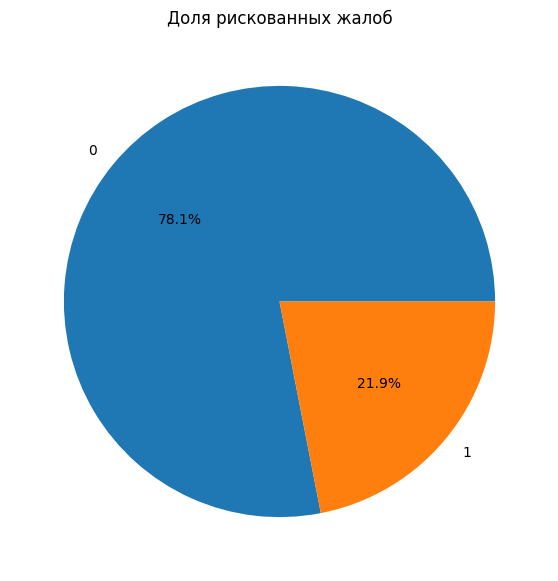

In [14]:
plt.figure(figsize=(7, 7))
plt.pie(risk_table['Count'], labels=risk_table['Risk'], autopct='%1.1f%%')
plt.title('Доля рискованных жалоб')
plt.show()

Анализ целевой переменной показавыет, что примерно 22% обращений относятся к категории повышенного риска, а оставшиеся 78% составляют обращения низкого риска.

Таким образом, примерно каждое пятое обращение требует повышенного внимания. Отметим, что объем рискованных обращений остается достаточно большим для последующего обучения модели прогнозирования риска.

3. Считаем количество жалоб по продуктам

In [15]:
product_count = df['Product'].value_counts().reset_index()
product_count.columns = ['Product', 'Count']
product_count

,Product,Count
0,Debt collection,23143
1,Checking or savings account,11671
2,Credit card,11373
3,"Money transfer, virtual currency, or money ser...",4998
4,Credit reporting or other personal consumer re...,2713


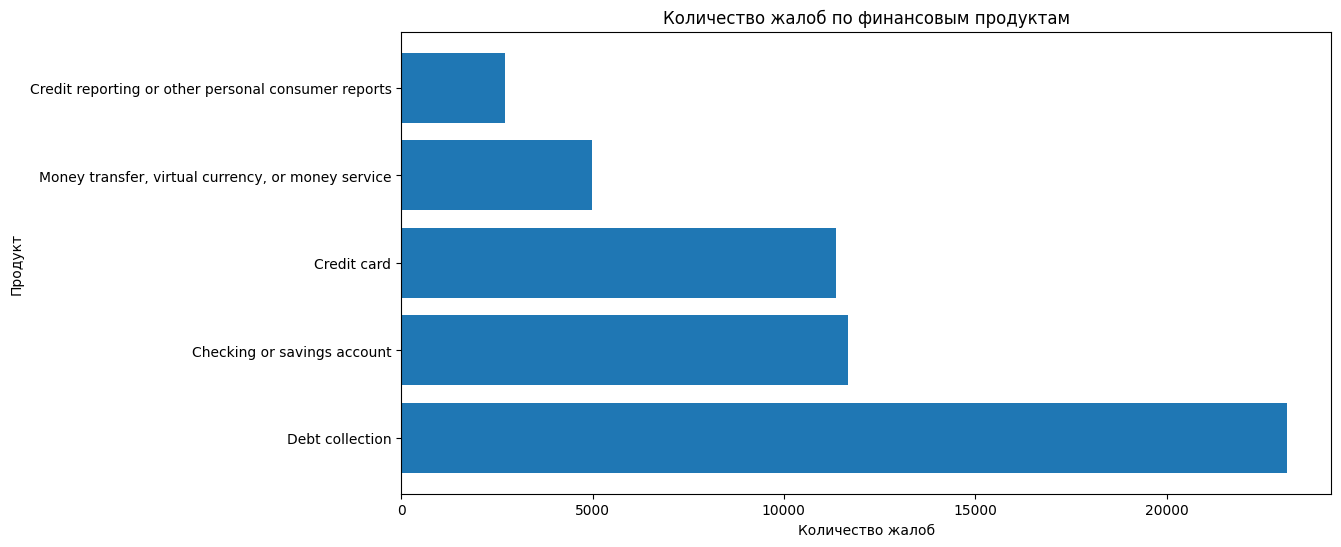

In [16]:
plt.figure(figsize=(12, 6))
plt.barh(product_count['Product'],product_count['Count'])

plt.title('Количество жалоб по финансовым продуктам')
plt.xlabel('Количество жалоб')
plt.ylabel('Продукт')
plt.show()

Считаем вероятность риска (доля Risk=1 внутри каждого продукта)

In [17]:
product_risk = df.groupby('Product')['Risk'].mean().reset_index()
product_risk['Risk'] = product_risk['Risk'] * 100
product_risk = product_risk.sort_values('Risk')

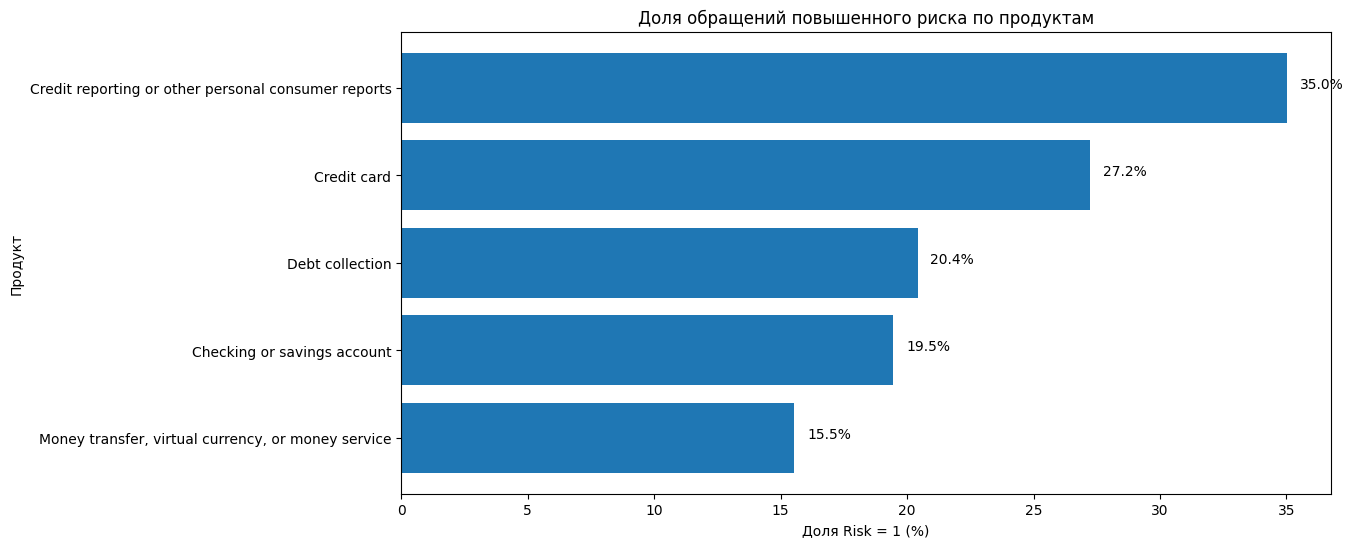

In [18]:
plt.figure(figsize=(12, 6))
plt.barh(product_risk['Product'] ,product_risk['Risk'])
for i in range(len(product_risk)):
    plt.text(product_risk['Risk'].iloc[i] + 0.5, i, str(round(product_risk['Risk'].iloc[i], 1)) + '%')

plt.title('Доля обращений повышенного риска по продуктам')
plt.xlabel('Доля Risk = 1 (%)')
plt.ylabel('Продукт')
plt.show()

Покажем одновременно: количество жалоб и долю риска.

In [19]:
product_summary = df.groupby('Product').agg({'Risk': 'mean'})
product_summary['Count'] = df['Product'].value_counts()
product_summary['Risk'] = product_summary['Risk'] * 100
product_summary = product_summary.reset_index()

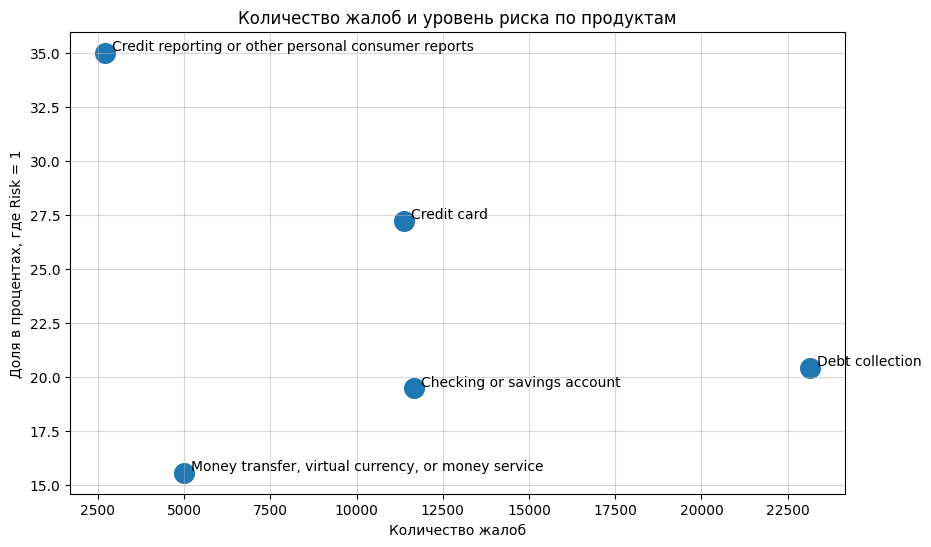

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(product_summary['Count'], product_summary['Risk'], s=200)
for i in range(len(product_summary)):
    plt.text(product_summary['Count'].iloc[i] + 200, product_summary['Risk'].iloc[i] + 0.1, product_summary['Product'].iloc[i])

plt.grid(alpha=0.5)
plt.title('Количество жалоб и уровень риска по продуктам')
plt.xlabel('Количество жалоб')
plt.ylabel('Доля в процентах, где Risk = 1')
plt.show()

Финансовые продукты демонстрируют различный уровень риска обращений. Наиболее рискованными являются продукты, связанные с кредитной отчетностью и кредитными картами, в свою очередь денежные переводы характеризуются более низкой долей обращений повышенного риска.

Это позволяет выделить направления, требующие приоритетного внимания при анализе и обработке клиентских жалоб.

4. Распределение жалоб по типам проблем

In [21]:
issue_count = df['Issue'].value_counts().reset_index()
issue_count.columns = ['Issue', 'Count']
issue_count

,Issue,Count
0,Other,15362
1,Attempts to collect debt not owed,12106
2,Managing an account,6592
3,Written notification about debt,3973
4,Problem with a purchase shown on your statement,3915
5,False statements or representation,3119
6,Took or threatened to take negative or legal a...,2049
7,Incorrect information on your report,1911
8,Problem with a lender or other company chargin...,1748
9,Closing an account,1597


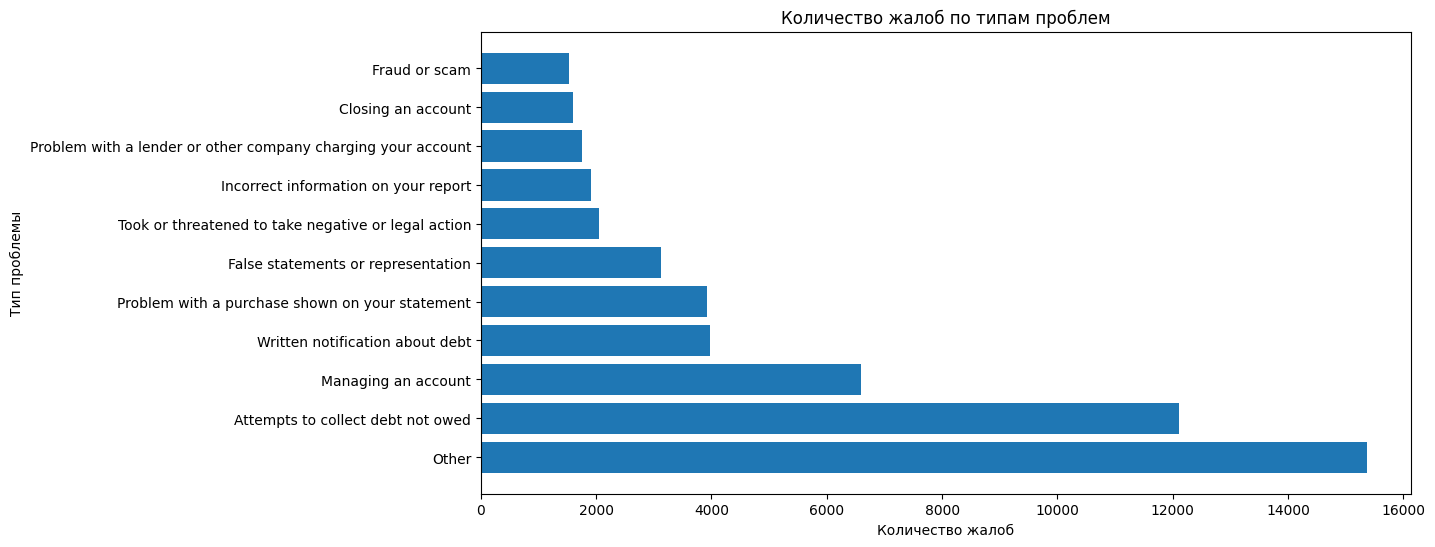

In [22]:
plt.figure(figsize=(12, 6))
plt.barh(issue_count['Issue'],issue_count['Count'])

plt.title('Количество жалоб по типам проблем')
plt.xlabel('Количество жалоб')
plt.ylabel('Тип проблемы')
plt.show()

Доля риска по проблемам (при Risk = 1)

In [23]:
issue_risk = df.groupby('Issue')['Risk'].mean().reset_index()
issue_risk['Risk'] = issue_risk['Risk'] * 100
issue_risk = issue_risk.sort_values('Risk')

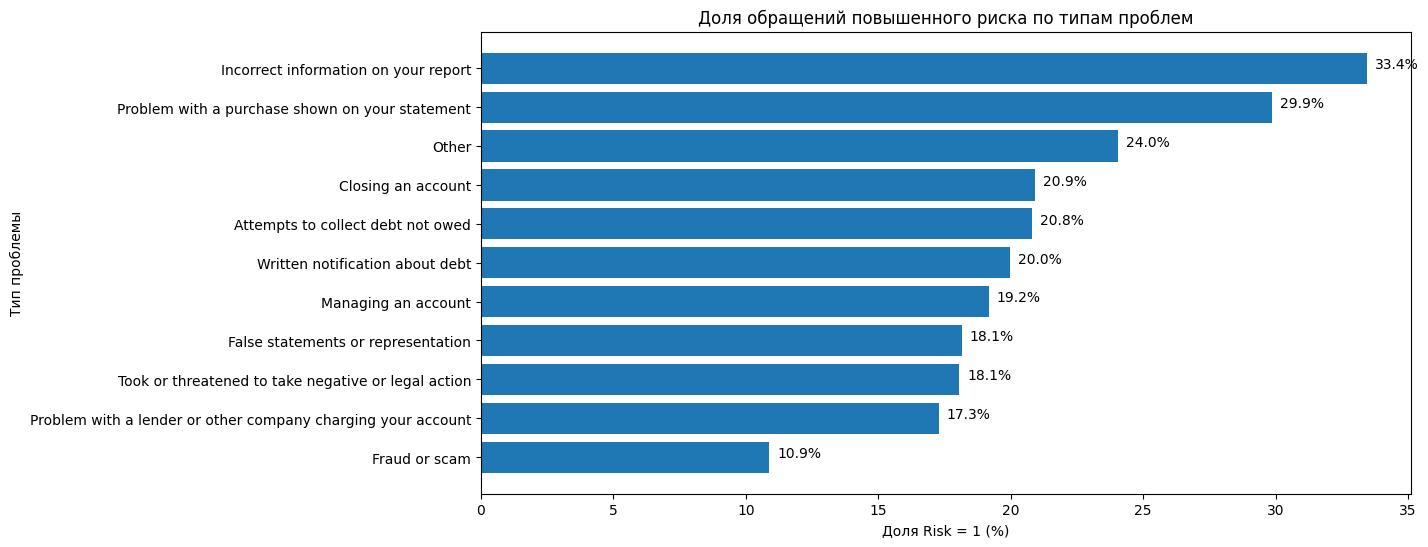

In [24]:
plt.figure(figsize=(12, 6))
plt.barh(issue_risk['Issue'],issue_risk['Risk'])

for i in range(len(issue_risk)):
  plt.text(issue_risk['Risk'].iloc[i] + 0.3, i, str(round(issue_risk['Risk'].iloc[i], 1)) + '%')

plt.title('Доля обращений повышенного риска по типам проблем')
plt.xlabel('Доля Risk = 1 (%)')
plt.ylabel('Тип проблемы')
plt.show()

Попробуем снова построить матрицу:
по оси X — количество жалоб;
по оси Y — доля риска.

In [25]:
issue_summary = df.groupby('Issue').agg({'Risk': 'mean'})
issue_summary['Count'] = df['Issue'].value_counts()
issue_summary['Risk'] = issue_summary['Risk'] * 100
issue_summary = issue_summary.reset_index()
x_mean = issue_summary['Count'].mean()
y_mean = issue_summary['Risk'].mean()

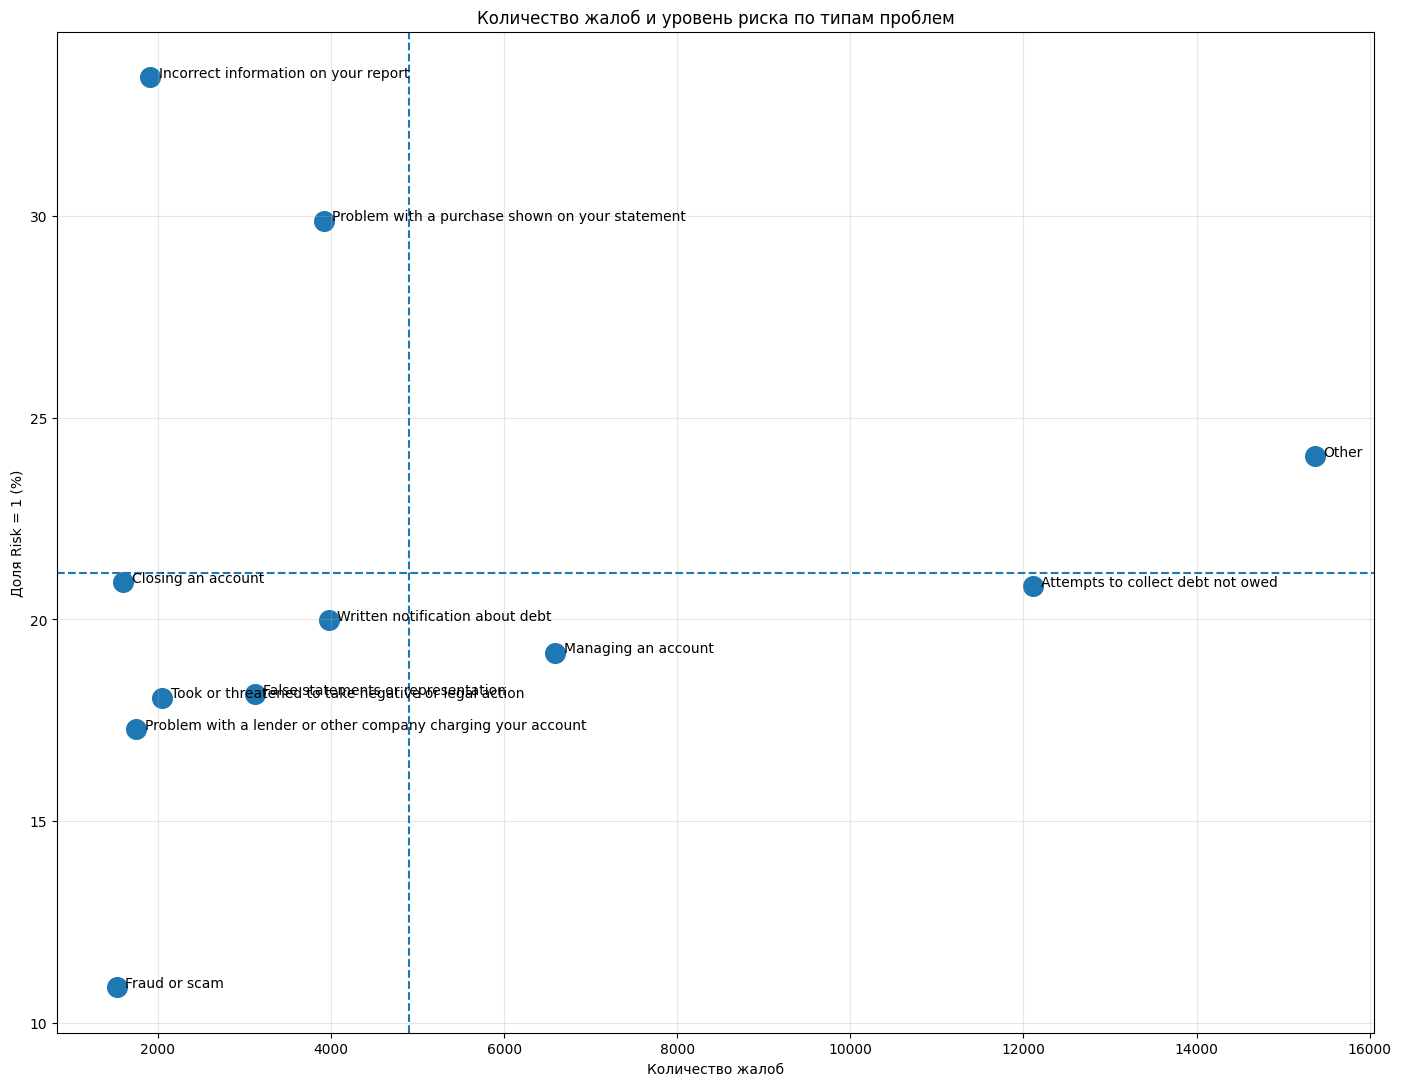

In [26]:
plt.figure(figsize=(17, 13))
plt.scatter(issue_summary['Count'], issue_summary['Risk'], s=200)

for i in range(len(issue_summary)):
    plt.text(issue_summary['Count'].iloc[i] + 100, issue_summary['Risk'].iloc[i], issue_summary['Issue'].iloc[i])


plt.axvline(x_mean, linestyle='--')
plt.axhline(y_mean, linestyle='--')

plt.grid(alpha=0.3)
plt.title('Количество жалоб и уровень риска по типам проблем')
plt.xlabel('Количество жалоб')
plt.ylabel('Доля Risk = 1 (%)')
plt.show()

**Горизонтальная пунктирная линия** показывает: Средний уровень риска по всем типам проблем.

**Вертикальная пунктирная линия** показывает: Среднее количество жалоб по всем типам проблем.

**Из-за этого образуются четыре зоны.**

Правый верхний квадрант
Много жалоб
+
Высокий риск
Самая важная зона. Это основные источники бизнес-риска.

Левый верхний квадрант
Мало жалоб
+
Высокий риск
Редкие, но потенциально критичные проблемы.

Правый нижний квадрант
Много жалоб
+
Низкий риск
Массовые проблемы, которые возникают часто, но реже приводят к серьезным последствиям.

Левый нижний квадрант
Мало жалоб
+
Низкий риск
Наименее приоритетная зона.

Наибольший интерес представляют проблемы, расположенные в правом верхнем квадрате, так как они сочетают высокий уровень риска с большим количеством жалоб. Именно эти категории могут рассматриваться как приоритетные направления для дальнейшего анализа и совершенствования процессов работы с клиентскими обращениями.

5. Связь Product и Issue - какие продукты более рискованные; какие проблемы более рискованные.

In [27]:
product_issue = pd.crosstab(df['Product'], df['Issue'])
product_issue

Issue,Attempts to collect debt not owed,Closing an account,False statements or representation,Fraud or scam,Incorrect information on your report,Managing an account,Other,Problem with a lender or other company charging your account,Problem with a purchase shown on your statement,Took or threatened to take negative or legal action,Written notification about debt
Product,,,,,,,,,,,
Checking or savings account,0,1597,0,0,30,6592,1704,1748,0,0,0
Credit card,0,0,0,0,475,0,6983,0,3915,0,0
Credit reporting or other personal consumer reports,0,0,0,0,1406,0,1307,0,0,0,0
Debt collection,12106,0,3119,0,0,0,1896,0,0,2049,3973
"Money transfer, virtual currency, or money service",0,0,0,1526,0,0,3472,0,0,0,0


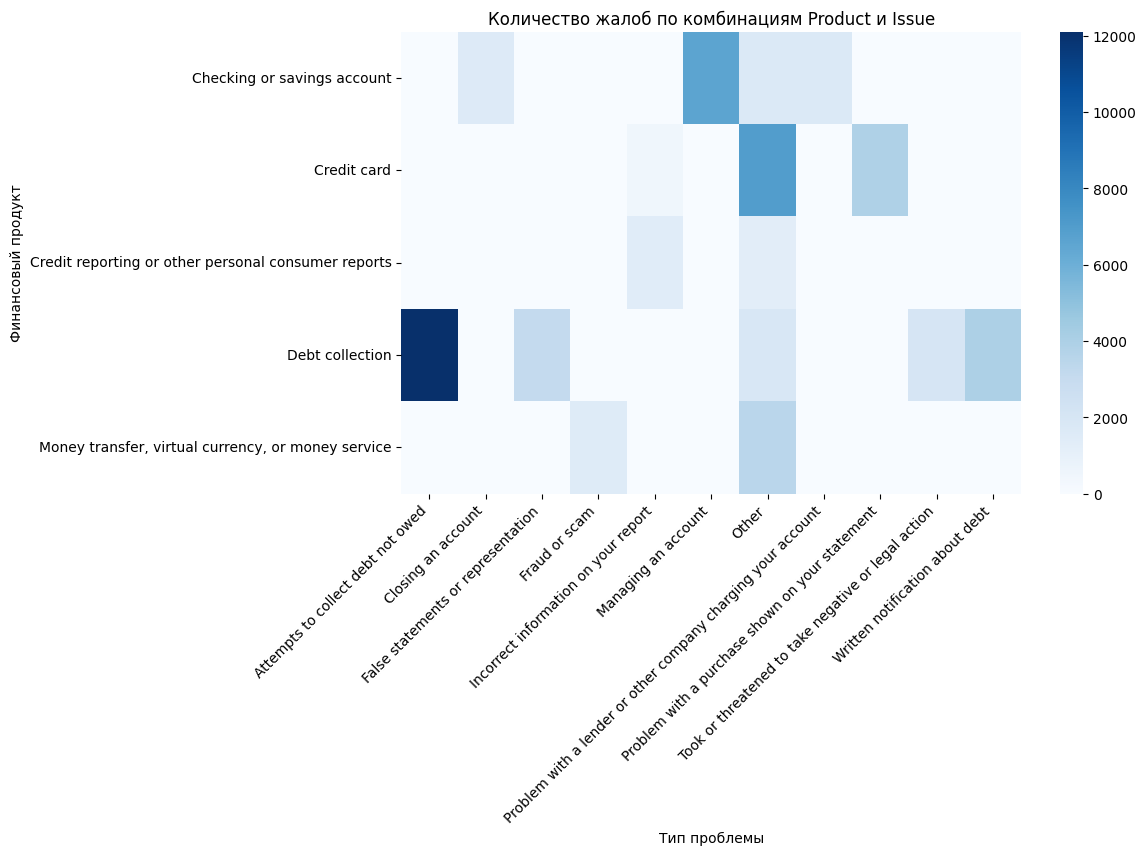

In [28]:
plt.figure(figsize=(10, 6))
sns.heatmap(product_issue, cmap='Blues')

plt.title('Количество жалоб по комбинациям Product и Issue')
plt.xlabel('Тип проблемы')
plt.ylabel('Финансовый продукт')
plt.xticks(rotation=45, ha='right')
plt.show()

Считаем средний риск для каждой комбинации (Product × Issue × Risk)

In [29]:
product_issue_risk = df.groupby(['Product', 'Issue'])['Risk'].mean().reset_index()
product_issue_risk['Risk'] = product_issue_risk['Risk'] * 100

In [30]:
product_issue_risk = product_issue_risk.pivot(index='Product', columns='Issue', values='Risk')

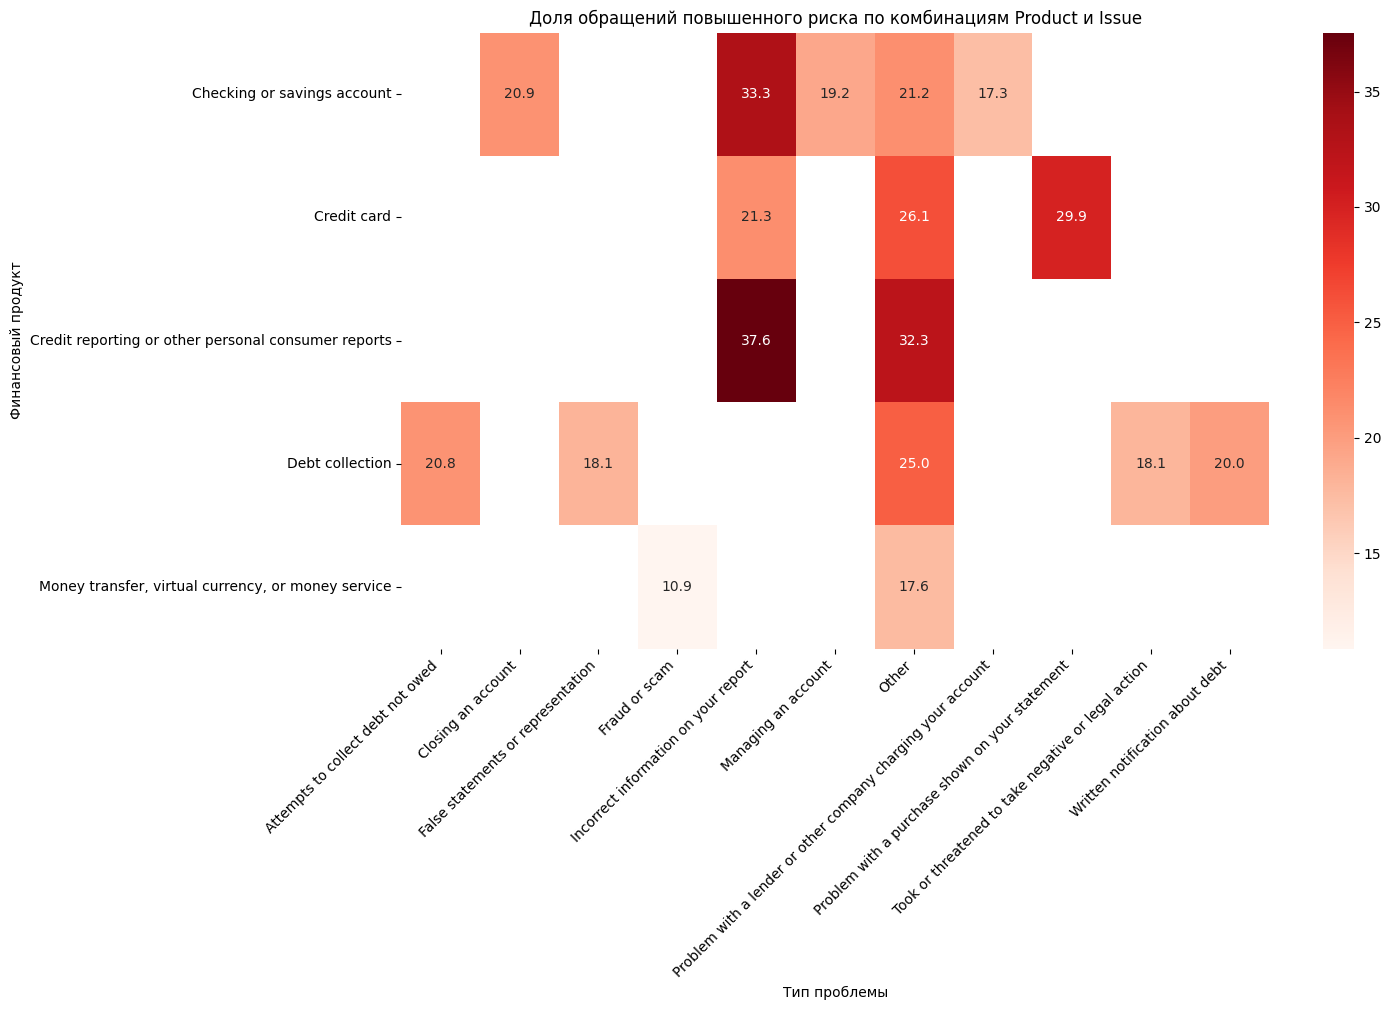

In [31]:
plt.figure(figsize=(14, 8))
sns.heatmap(product_issue_risk, annot=True, fmt='.1f', cmap='Reds')

plt.title('Доля обращений повышенного риска по комбинациям Product и Issue')
plt.xlabel('Тип проблемы')
plt.ylabel('Финансовый продукт')
plt.xticks(rotation=45, ha='right')
plt.show()

То есть мы имеем в виду, что уровень риска определяется не только самим продуктом или проблемой по отдельности, а их сочетанием. Для ряда комбинаций наблюдается существенно более высокая доля обращений повышенного риска по сравнению со средним уровнем по данным.

Это наблюдение позволяет определить наиболее проблемные сценарии взаимодействия клиентов с финансовыми организациями, чтобы выбрать приоритетные направления для анализа.

Перейдем к портрету рискованной жалобы

Попробуем определить чем отличается рискованная жалоба от обычной?

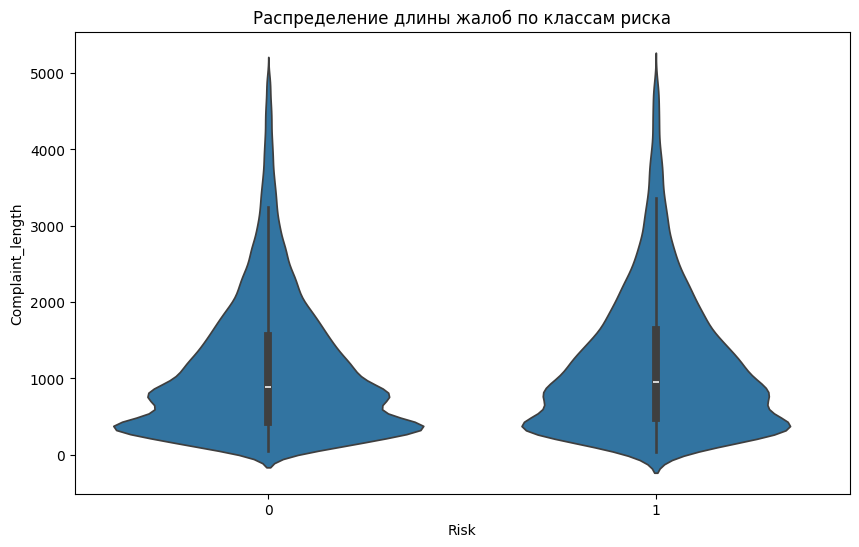

In [32]:
a = df[df['Complaint_length'] < 5000]
plt.figure(figsize=(10, 6))

sns.violinplot(data=a, x='Risk', y='Complaint_length')
plt.title('Распределение длины жалоб по классам риска')
plt.xlabel('Risk')
plt.ylabel('Complaint_length')
plt.show()

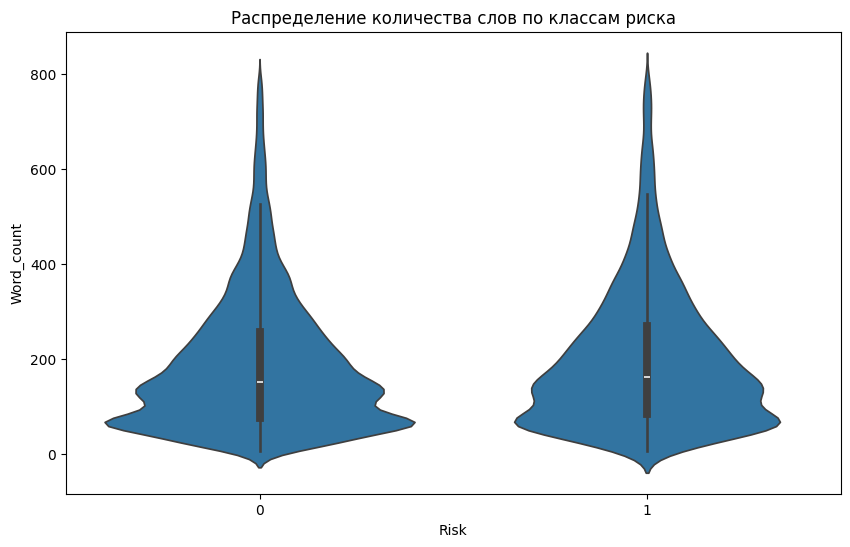

In [33]:
a = df[df['Word_count'] < 800]
plt.figure(figsize=(10, 6))
sns.violinplot(data=a, x='Risk', y='Word_count')

plt.title('Распределение количества слов по классам риска')
plt.xlabel('Risk')
plt.ylabel('Word_count')
plt.show()

In [34]:
length_stats = df.groupby('Risk')[['Complaint_length', 'Word_count']].mean()
length_stats

,Complaint_length,Word_count
Risk,,
0,1219.305884,202.717144
1,1288.866920,215.261421


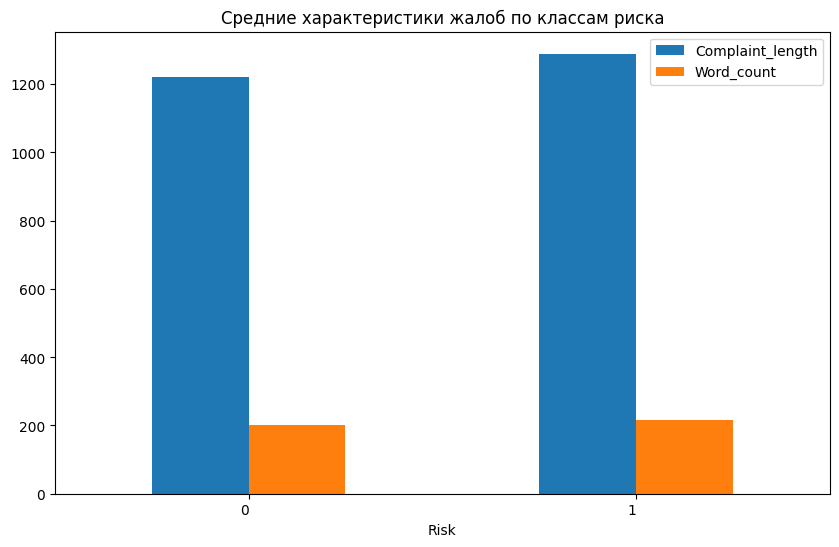

In [35]:
length_stats.plot(kind='bar',figsize=(10, 6))
plt.title('Средние характеристики жалоб по классам риска')
plt.xticks(rotation=0, ha='right')
plt.show()

Анализ текстовых характеристик обращений показал, что жалобы повышенного риска отличаются от обычных не только содержанием, но и объемом текста. В среднем рискованные обращения содержат более подробное описание проблемы, что может говорить о повышенной сложности рассматриваемых случаев и большем уровне вовлеченности клиента в процесс подачи жалобы.

7. Когда возникают рискованные обращения

Здесь мы анализируем:
hour
day_of_week
month

In [38]:
hour_count = df['hour'].value_counts().sort_index()

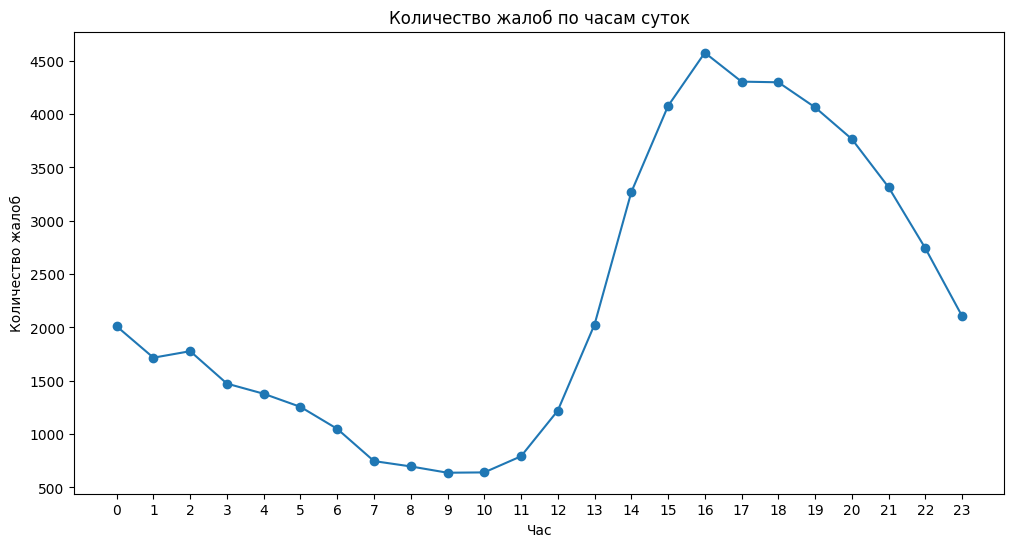

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(hour_count.index, hour_count.values, marker='o')

plt.title('Количество жалоб по часам суток')
plt.xlabel('Час')
plt.ylabel('Количество жалоб')
plt.xticks(range(24))
plt.show()

In [40]:
hour_risk = df.groupby('hour')['Risk'].mean() * 100

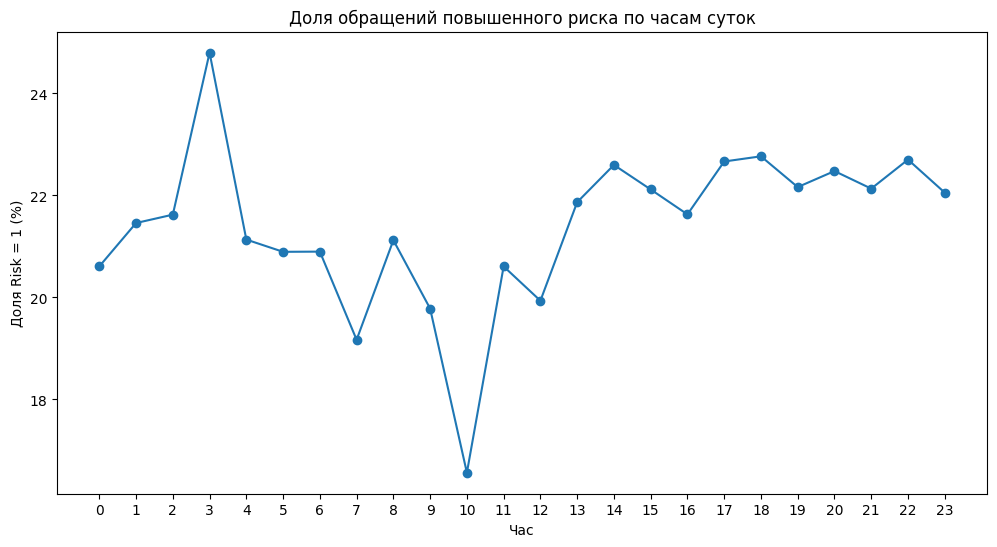

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(hour_risk.index, hour_risk.values, marker='o')

plt.title('Доля обращений повышенного риска по часам суток')
plt.xlabel('Час')
plt.ylabel('Доля Risk = 1 (%)')
plt.xticks(range(24))
plt.show()

In [42]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [43]:
day_count = df['day_of_week'].value_counts()
day_count = day_count.reindex(days)

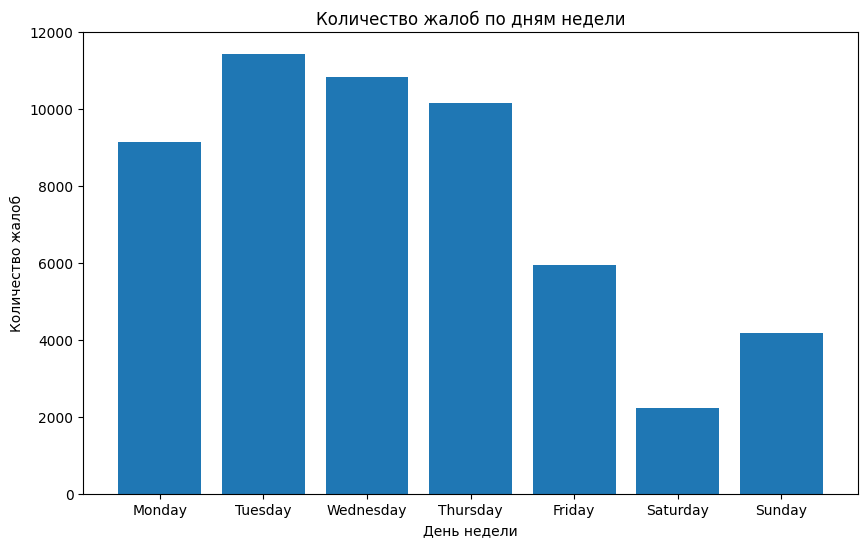

In [44]:
plt.figure(figsize=(10, 6))
plt.bar(day_count.index, day_count.values)

plt.title('Количество жалоб по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество жалоб')
plt.show()

In [45]:
day_risk = df.groupby('day_of_week')['Risk'].mean() * 100
day_risk = day_risk.reindex(days)

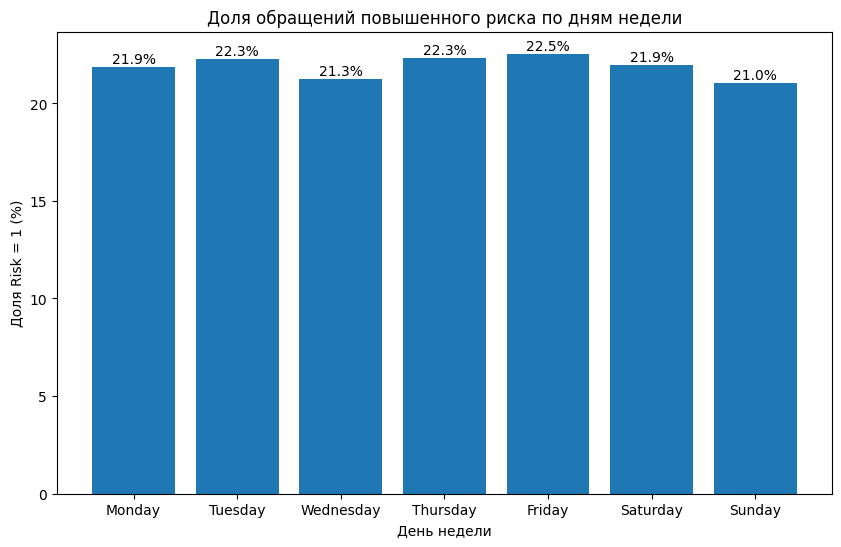

In [46]:
plt.figure(figsize=(10, 6))
plt.bar(day_risk.index, day_risk.values)
for i in range(len(day_risk)):
    plt.text(i, day_risk.iloc[i] + 0.2, str(round(day_risk.iloc[i], 1)) + '%', ha='center')

plt.title('Доля обращений повышенного риска по дням недели')
plt.xlabel('День недели')
plt.ylabel('Доля Risk = 1 (%)')
plt.show()

In [47]:
month_count = df['month'].value_counts().sort_index()

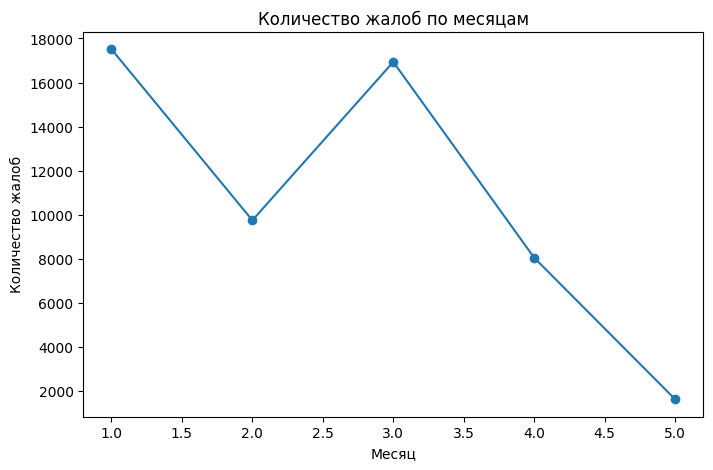

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(month_count.index, month_count.values, marker='o')

plt.title('Количество жалоб по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество жалоб')
plt.show()

In [49]:
month_risk = df.groupby('month')['Risk'].mean() * 100

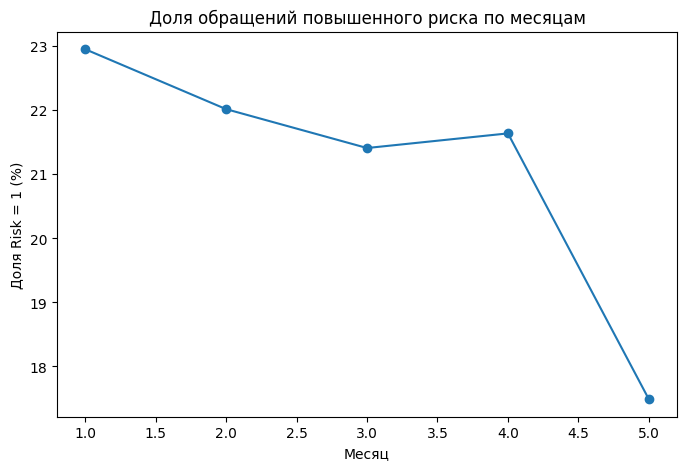

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(month_risk.index, month_risk.values, marker='o')

plt.title('Доля обращений повышенного риска по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Доля Risk = 1 (%)')
plt.show()

In [51]:
hour_day = pd.pivot_table(df, values='Risk', index='day_of_week', columns='hour', aggfunc='mean')
hour_day = hour_day.reindex(days)

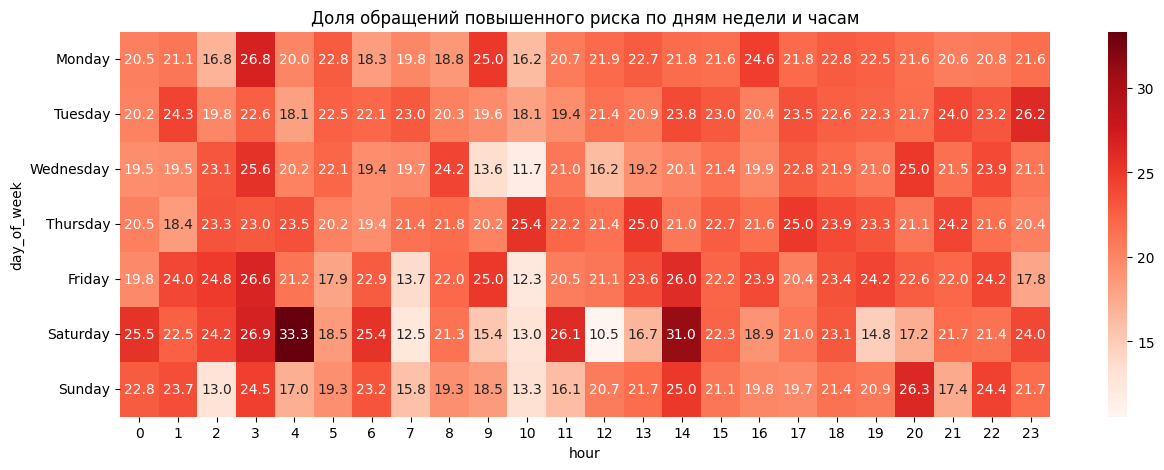

In [52]:
plt.figure(figsize=(15, 5))
sns.heatmap(hour_day * 100, annot=True, fmt='.1f', cmap='Reds')

plt.title('Доля обращений повышенного риска по дням недели и часам')
plt.show()

8. Корреляционный анализ признаков

Попробуем понять, какие признаки числовые связаны между собой

In [53]:
corr = df[['Complaint_length', 'Word_count', 'month', 'hour', 'Risk']].corr()
corr

,Complaint_length,Word_count,month,hour,Risk
Complaint_length,1.000000,0.992762,0.030510,-0.026855,0.023154
Word_count,0.992762,1.000000,0.030218,-0.024551,0.025608
month,0.030510,0.030218,1.000000,-0.005808,-0.020448
hour,-0.026855,-0.024551,-0.005808,1.000000,0.009980
Risk,0.023154,0.025608,-0.020448,0.009980,1.000000


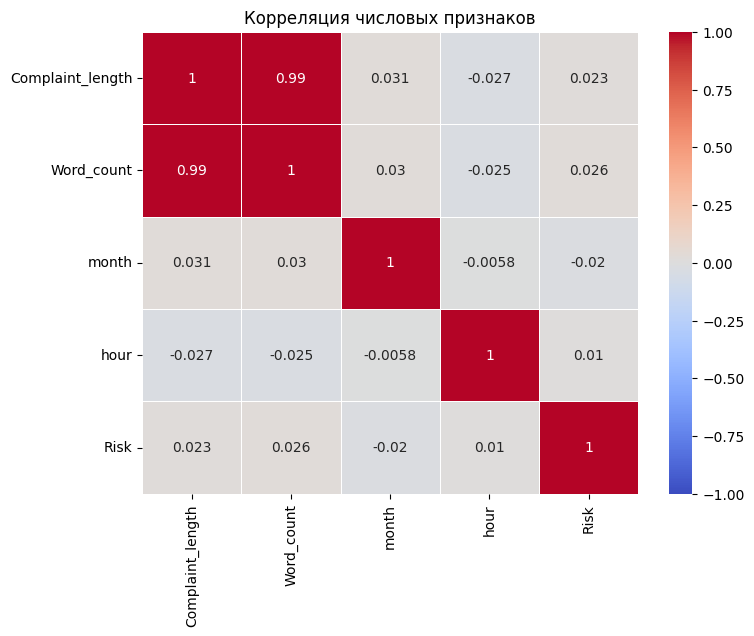

In [63]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Корреляция числовых признаков')
plt.show()

Посмотрим на связь длины жалобы и количества слов.

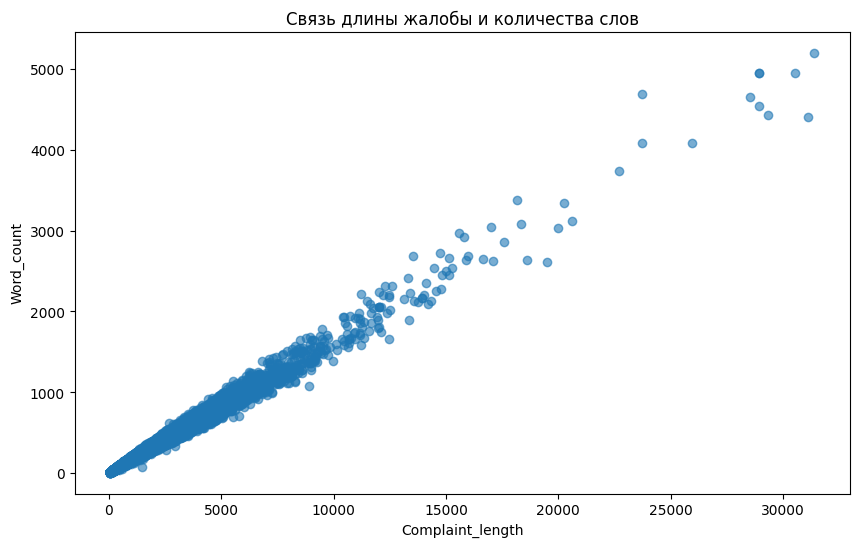

In [64]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Complaint_length'], df['Word_count'], alpha=0.6)
plt.title('Связь длины жалобы и количества слов')
plt.xlabel('Complaint_length')
plt.ylabel('Word_count')
plt.show()

Корреляционный анализ показал сильную положительную связь между длиной жалобы и количеством слов, что абсолютно логично, так как длина буквально формируется количеством слов.

В остальном числовые признаки демонстрируют слабые корреляции как между собой, так и с целевой переменной. Это можно интерпретировать как то, что риск обращения это скорее совокупность факторов, а не какой-то отдельный признак в датасете и его отдельное влияние на целевую переменную.

9. Анализ компаний

Топ-10 компаний по количеству жалоб

In [65]:
company_count = df['Company'].value_counts().head(10)
company_count = company_count.reset_index()
company_count.columns = ['Company', 'Count']
company_count

,Company,Count
0,WELLS FARGO & COMPANY,2588
1,"CITIBANK, N.A.",2586
2,JPMORGAN CHASE & CO.,2152
3,"BANK OF AMERICA, NATIONAL ASSOCIATION",2136
4,CAPITAL ONE FINANCIAL CORPORATION,2086
5,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2021
6,"Block, Inc.",2004
7,CL Holdings LLC,1777
8,"Paypal Holdings, Inc",1598
9,Experian Information Solutions Inc.,1510


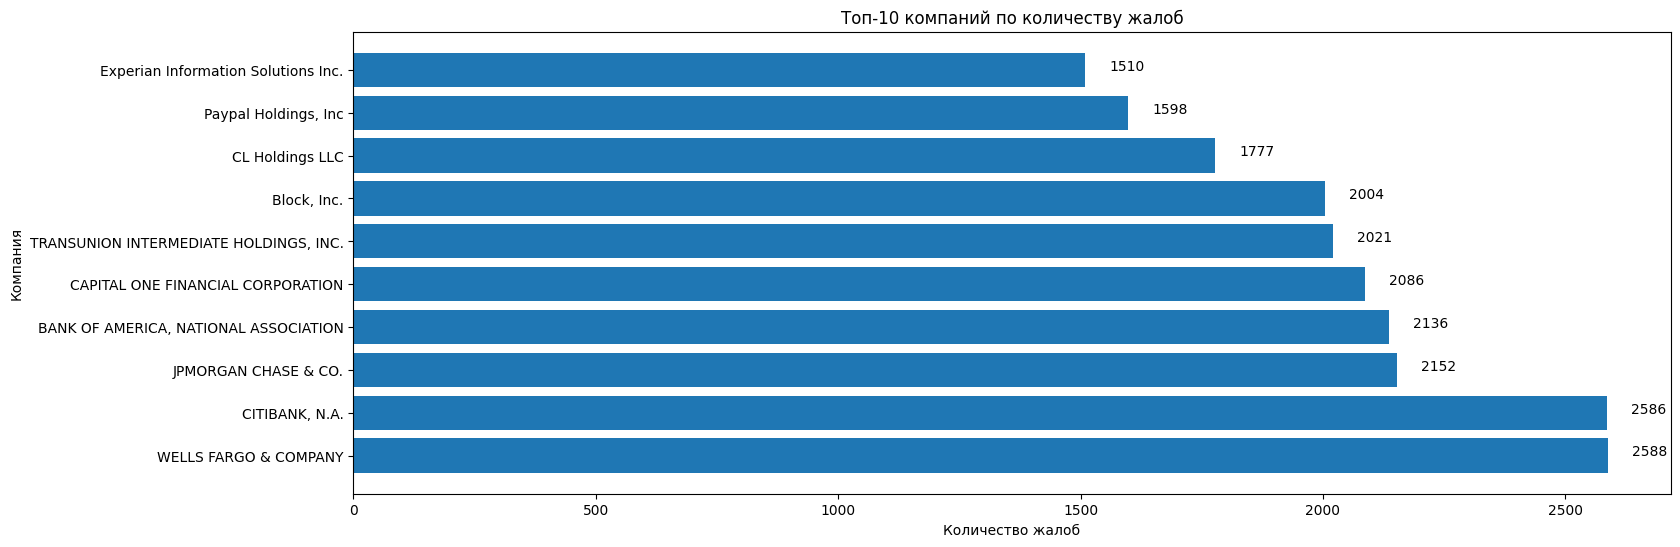

In [75]:
plt.figure(figsize=(17, 6))
plt.barh(company_count['Company'], company_count['Count'])
for i in range(len(company_count)):
    plt.text(company_count['Count'].iloc[i] + 50, i, company_count['Count'].iloc[i])

plt.title('Топ-10 компаний по количеству жалоб')
plt.xlabel('Количество жалоб')
plt.ylabel('Компания')
plt.show()

Топ-10 компаний по доле обращений повышенного риска

In [76]:
company_size = df['Company'].value_counts()
good_companies = company_size[company_size >= 100].index

In [77]:
company_risk = df[df['Company'].isin(good_companies)]
company_risk = company_risk.groupby('Company')['Risk'].mean()
company_risk = company_risk * 100
company_risk = company_risk.sort_values(ascending=False).head(10)
company_risk = company_risk.reset_index()
company_risk.columns = ['Company', 'Risk']

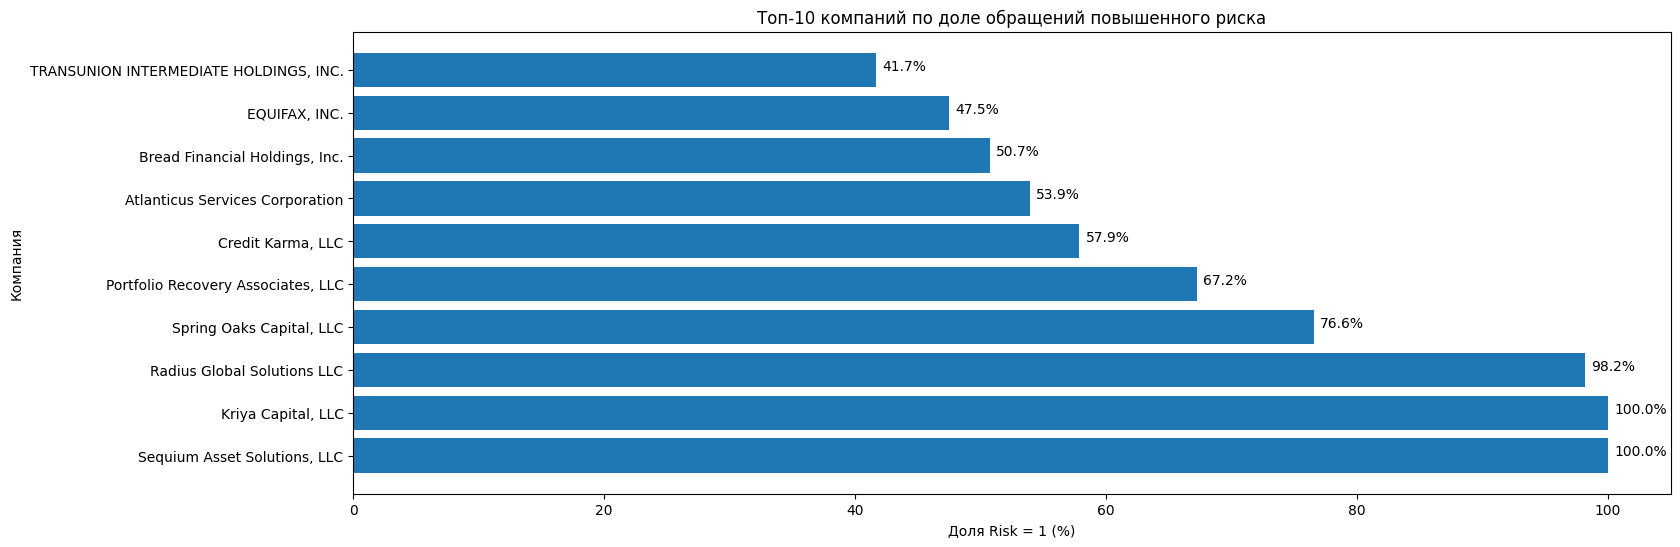

In [79]:
plt.figure(figsize=(17, 6))
plt.barh(company_risk['Company'], company_risk['Risk'])
for i in range(len(company_risk)):
    plt.text(company_risk['Risk'].iloc[i] + 0.5, i, str(round(company_risk['Risk'].iloc[i], 1)) + '%')

plt.title('Топ-10 компаний по доле обращений повышенного риска')
plt.xlabel('Доля Risk = 1 (%)')
plt.ylabel('Компания')
plt.show()

In [81]:
company_summary = df.groupby('Company').agg({'Risk': 'mean'})
company_summary['Count'] = df['Company'].value_counts()
company_summary['Risk'] = company_summary['Risk'] * 100
company_summary = company_summary.reset_index()
company_summary = company_summary[company_summary['Count'] >= 100]
x_mean = company_summary['Count'].mean()
y_mean = company_summary['Risk'].mean()

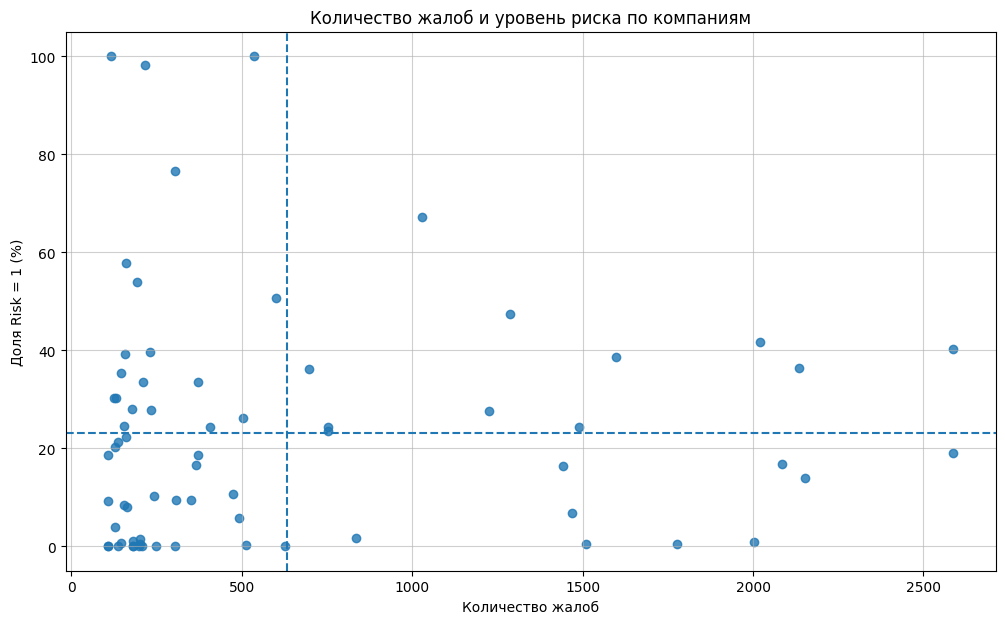

In [84]:
plt.figure(figsize=(12, 7))
plt.scatter(company_summary['Count'], company_summary['Risk'], alpha=0.8)
plt.axvline(x_mean, linestyle='--')
plt.axhline(y_mean,linestyle='--')

plt.title('Количество жалоб и уровень риска по компаниям')
plt.xlabel('Количество жалоб')
plt.ylabel('Доля Risk = 1 (%)')
plt.grid(alpha=0.6)
plt.show()

Здесь по графику особенно интересна верхняя область, где у нас пересечение большого количество жалоб и высокого риска. Как вы видим, такие компании реально есть, их не мало, а значит они оказывают существенное влияние на анализ риска жалоб.

Попробуем учесть это в дальнейшем анализе.

10. Портрет обращения высокого риска

В финале данного анализа попробуем составить общий портрет для обращения высокого риска

Для начала соберем информацию о самых популярных сущностях внтури Risk = 1 и Risk = 0

Средняя длина жалобы

In [85]:
length_profile = df.groupby('Risk')[['Complaint_length', 'Word_count']].mean()
length_profile

,Complaint_length,Word_count
Risk,,
0,1219.305884,202.717144
1,1288.866920,215.261421


Самый популярный продукт

In [86]:
risk_product = df.groupby('Risk')['Product'].agg(lambda x: x.value_counts().index[0])
risk_product

,Product
Risk,
0,Debt collection
1,Debt collection


Самая популярная проблема

In [87]:
risk_issue = df.groupby('Risk')['Issue'].agg(lambda x: x.value_counts().index[0])
risk_issue

,Issue
Risk,
0,Other
1,Other


Самая популярная компания

In [88]:
risk_company = df.groupby('Risk')['Company'].agg(lambda x: x.value_counts().index[0])
risk_company

,Company
Risk,
0,WELLS FARGO & COMPANY
1,"CITIBANK, N.A."


Самый популярный месяц

In [102]:
risk_month = df.groupby('Risk')['month'].agg(lambda x: x.value_counts().index[0])
risk_month

,month
Risk,
0,1
1,1


Самый популярный день недели

In [89]:
risk_day = df.groupby('Risk')['day_of_week'].agg(lambda x: x.value_counts().index[0])
risk_day

,day_of_week
Risk,
0,Tuesday
1,Tuesday


Самый популярный час

In [90]:
risk_hour = df.groupby('Risk')['hour'].agg(lambda x: x.value_counts().index[0])
risk_hour

,hour
Risk,
0,16
1,16


Соберем всё это в одну общую таблицу

In [135]:
profile = pd.DataFrame({
    'Risk_0': [risk_product[0], risk_issue[0], risk_company[0], risk_month[0], risk_day[0], risk_hour[0], round(length_profile.loc[0, 'Complaint_length']), round(length_profile.loc[0, 'Word_count'])],
    'Risk_1': [risk_product[1], risk_issue[1], risk_company[1], risk_month[1], risk_day[1], risk_hour[1], round(length_profile.loc[1, 'Complaint_length']), round(length_profile.loc[1, 'Word_count'])]
    })

profile.index = [
    'Самый популярный продукт',
    'Самая популярная проблема',
    'Самая популярная компания',
    'Самый популярный месяц',
    'Самый популярный день недели',
    'Самый популярный час',
    'Средняя длина жалобы',
    'Среднее количество слов'
]

profile.style.set_caption('Портрет обращений низкого и выского риска')

,Risk_0,Risk_1
Самый популярный продукт,Debt collection,Debt collection
Самая популярная проблема,Other,Other
Самая популярная компания,WELLS FARGO & COMPANY,"CITIBANK, N.A."
Самый популярный месяц,1,1
Самый популярный день недели,Tuesday,Tuesday
Самый популярный час,16,16
Средняя длина жалобы,1219,1289
Среднее количество слов,203,215


А теперь по аналогии соберем информацию о самых рискованных сущностях (Risk = 1), то есть мы ищем значения с максимальной долей риска среди других значений.

Самый рискованный продукт

In [96]:
most_risky_product = product_risk.sort_values('Risk', ascending=False)['Product'].iloc[0]
most_risky_product

'Credit reporting or other personal consumer reports'

Самая рискованная проблема

In [97]:
most_risky_issue = issue_risk.sort_values('Risk', ascending=False)['Issue'].iloc[0]
most_risky_issue

'Incorrect information on your report'

Самая рискованная компания

In [98]:
most_risky_company = company_risk.sort_values('Risk', ascending=False)['Company'].iloc[0]
most_risky_company

'Sequium Asset Solutions, LLC'

Самый рискованный месяц

In [101]:
month_risk = df.groupby('month')['Risk'].mean() * 100
most_risky_month = month_risk.sort_values(ascending=False).index[0]
most_risky_month

np.int64(1)

Самый рискованный день недели

In [99]:
day_risk = df.groupby('day_of_week')['Risk'].mean() * 100
most_risky_day = day_risk.sort_values(ascending=False).index[0]
most_risky_day

'Friday'

Самый рискованный час

In [100]:
hour_risk = df.groupby('hour')['Risk'].mean() * 100
most_risky_hour = hour_risk.sort_values(ascending=False).index[0]
most_risky_hour

np.int64(3)

Также соберем всё в таблицу

In [115]:
risk_factors = pd.DataFrame({
    'Характеристика': [
        'Самый рискованный продукт',
        'Самая рискованная проблема',
        'Самая рискованная компания',
        'Самый рискованный день недели',
        'Самый рискованный час',
        'Самый рискованный месяц'
    ],
    'Значение': [
        most_risky_product,
        most_risky_issue,
        most_risky_company,
        most_risky_day,
        most_risky_hour,
        most_risky_month
    ]
})

risk_factors.style.set_caption('Факторы, наиболее связанные с высоким риском')

,Характеристика,Значение
0,Самый рискованный продукт,Credit reporting or other personal consumer reports
1,Самая рискованная проблема,Incorrect information on your report
2,Самая рискованная компания,"Sequium Asset Solutions, LLC"
3,Самый рискованный день недели,Friday
4,Самый рискованный час,3
5,Самый рискованный месяц,1


Сделаем таблицы красивее!

In [119]:
!pip install great-tables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.0/451.0 kB 26.7 MB/s eta 0:00:00


In [126]:
from great_tables import GT

In [136]:
profile_show = profile.reset_index()
profile_show.columns = ['Характеристика', 'Низкий риск', 'Высокий риск']
GT(profile_show).tab_header(title='Портрет обращений низкого и высокого риска')

GT(_tbl_data=                 Характеристика            Низкий риск     Высокий риск
0      Самый популярный продукт        Debt collection  Debt collection
1     Самая популярная проблема                  Other            Other
2     Самая популярная компания  WELLS FARGO & COMPANY   CITIBANK, N.A.
3        Самый популярный месяц                      1                1
4  Самый популярный день недели                Tuesday          Tuesday
5          Самый популярный час                     16               16
6          Средняя длина жалобы                   1219             1289
7       Среднее количество слов                    203              215, _body=<great_tables._gt_data.Body object at 0x7c4be67548f0>, _boxhead=Boxhead([ColInfo(var='Характеристика', type=<ColInfoTypeEnum.default: 1>, column_label='Характеристика', column_align='left', column_width=None), ColInfo(var='Низкий риск', type=<ColInfoTypeEnum.default: 1>, column_label='Низкий риск', column_align='left', column_width=None), ColInfo(var='Высокий риск', type=<ColInfoTypeEnum.default: 1>, column_label='Высокий риск', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7c4be600b650>, _spanners=Spanners([]), _heading=Heading(title='Портрет обращений низкого и высокого риска', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7c4be6fff4a0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7c4be60086e0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7c4be6042150>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', 

In [132]:
GT(risk_factors).tab_header(title='Факторы, наиболее связанные с высоким риском')

GT(_tbl_data=                  Характеристика  \
0      Самый рискованный продукт   
1     Самая рискованная проблема   
2     Самая рискованная компания   
3  Самый рискованный день недели   
4          Самый рискованный час   
5        Самый рискованный месяц   

                                            Значение  
0  Credit reporting or other personal consumer re...  
1               Incorrect information on your report  
2                       Sequium Asset Solutions, LLC  
3                                             Friday  
4                                                  3  
5                                                  1  , _body=<great_tables._gt_data.Body object at 0x7c4be6f153a0>, _boxhead=Boxhead([ColInfo(var='Характеристика', type=<ColInfoTypeEnum.default: 1>, column_label='Характеристика', column_align='left', column_width=None), ColInfo(var='Значение', type=<ColInfoTypeEnum.default: 1>, column_label='Значение', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7c4be6f14380>, _spanners=Spanners([]), _heading=Heading(title='Факторы, наиболее связанные с высоким риском', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7c4be6f17e60>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7c4be6f17e90>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7c4be6f17fb0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInf

Документация на использованную библиотеку: https://pypi.org/project/great-tables/

11. Итоговые выводы и бизнес-инстайты для ГП

Попробуем выделить из нашего анализа и наблюдений бизнес-инсайты, которые далее помогут нам в работе с обучениями моделей:

1. Рискованные жалобы, как правило, длиннее и имеют в среднем большое количество слов. То есть из этого можно сделать вывод о том, что рискованные ситуации обычно описываются клиентами более подробно и развернуто.

2. Корелляционный анализ показал, что числовые переменные по отдельности слабо связаны с повышенным риском. Глобально, если рассматривать их совместно друг с другом, то определенную пользу извлечь можно, однако бОльшее внимание в дальнейшей работе стоит уделить именно категориальным признакам и их кодированию.

3. Компании сильно отличаются по уровню риска между собой, но особенно важно учитывать общее количество жалоб, которые поступают в конкретную компанию.

4. Из 2-го пункта также вытекает наблюдения о том, что эффективнее смотреть на комбинацию продукта и проблемы, чем на отдельный продукт или отдельную проблему. Такой подход выходит более информативным, потому что мы можем составить определенную картину обращения конкретного пользователя.

5. Самые массовые категории не всегда являются самыми рискованными. То есть одна категория может встречаться сильно чаще остальных, но при этом иметь сравнительно невысокую долю повышенного риска обращений. Очень важно в дальнейшем анализе учитывать процент Risk = 1 внутри категории.

6. В нашем датасете приблизительно каждое пятое обращение имеет повышенный риск Risk = 1, а значит задача автоматического определения риска действительно имеет практический смысл.

7. Обращения с повышенным риском распределены по финансовым продуктам неравномерно. Можно выделить продукты, которые связаны с повышенным риском заметно чаще. К примеру, так можно отметить обращения по кредитной отчетности и обращения по кредитным картам клиентов.